RUNTIME: CPU (no GPU needed for this notebook)    
INSTRUCTIONS:

1. Set runtime to CPU: Runtime → Change runtime type → None
2. Run all cells in order: Runtime → Run all
3. When prompted, authorize Google Drive access
4. To save results/figures to GitHub:    
    a. Right-click the file in the left sidebar → Download  
    b. Go to the GitHub repo → results/ → Add file → Upload files   
    c. Commit directly on GitHub    
5. Save the notebook: Ctrl+S → save to GitHub when prompted

In [ ]:
# ── 1. Mount Google Drive ─────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
SAVE_DIR = "/content/drive/MyDrive/cs4120_project/" #change if desired

# ── 2. Standard imports ───────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.metrics import f1_score, classification_report

# GoEmotions Preprocessing and Exploratory Data Analysis

## Objectives
This notebook covers the initial data loading, preprocessing, and exploratory data analysis (EDA) for the GoEmotions dataset. In particular, it:
- loads the dataset from Hugging Face,
- inspects dataset splits and schema,
- examines class imbalance,
- computes text length statistics,
- analyzes multi-label structure,
- studies label co-occurrence patterns,
- defines reusable preprocessing functions for later modeling.

These analyses support the project's early-phase tasks on data understanding and preprocessing.

In [13]:
import re
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.preprocessing import MultiLabelBinarizer

In [14]:
# Plot / dataframe display settings
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

RANDOM_SEED = 42

## 1. Load Dataset

We load the GoEmotions dataset using the Hugging Face `datasets` library.  
GoEmotions is a multi-label emotion classification dataset of Reddit comments.

In [15]:
dataset = load_dataset("go_emotions")
dataset

split_sizes = {split: len(dataset[split]) for split in dataset.keys()}
split_sizes

{'train': 43410, 'validation': 5426, 'test': 5427}

## 2. Inspect Dataset Splits and Columns

This section checks:
- available dataset splits,
- feature columns,
- one example from each split,
- label metadata.

In [16]:
for split in dataset.keys():
    print(f"\n=== {split.upper()} ===")
    print(dataset[split])
    print("Columns:", dataset[split].column_names)
    print("First example:", dataset[split][0])

train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

train_df.head()


=== TRAIN ===
Dataset({
    features: ['text', 'labels', 'id'],
    num_rows: 43410
})
Columns: ['text', 'labels', 'id']
First example: {'text': "My favourite food is anything I didn't have to cook myself.", 'labels': [27], 'id': 'eebbqej'}

=== VALIDATION ===
Dataset({
    features: ['text', 'labels', 'id'],
    num_rows: 5426
})
Columns: ['text', 'labels', 'id']
First example: {'text': 'Is this in New Orleans?? I really feel like this is New Orleans.', 'labels': [27], 'id': 'edgurhb'}

=== TEST ===
Dataset({
    features: ['text', 'labels', 'id'],
    num_rows: 5427
})
Columns: ['text', 'labels', 'id']
First example: {'text': 'I’m really sorry about your situation :( Although I love the names Sapphira, Cirilla, and Scarlett!', 'labels': [25], 'id': 'eecwqtt'}
Train shape: (43410, 3)
Validation shape: (5426, 3)
Test shape: (5427, 3)


,text,labels,id
0,My favourite food is anything I didn't have to cook myself.,[27],eebbqej
1,"Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj


## 3. Extract Label Names

The `labels` column stores integer label IDs.  
We recover the human-readable emotion names from the dataset feature metadata.

In [17]:
label_feature = dataset["train"].features["labels"].feature
label_names = label_feature.names

print("Number of labels:", len(label_names))
print(label_names)

id2label = {i: label for i, label in enumerate(label_names)}
label2id = {label: i for i, label in enumerate(label_names)}

Number of labels: 28
['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


## 4. Add Derived Columns

To support EDA, we add:
- number of labels per example,
- character length,
- word length,
- decoded label names.

In [18]:
def add_eda_columns(df, id2label):
    df = df.copy()
    df["num_labels"] = df["labels"].apply(len)
    df["char_len"] = df["text"].astype(str).apply(len)
    df["word_len"] = df["text"].astype(str).apply(lambda x: len(x.split()))
    df["label_names"] = df["labels"].apply(lambda ids: [id2label[i] for i in ids])
    return df

train_df = add_eda_columns(train_df, id2label)
val_df = add_eda_columns(val_df, id2label)
test_df = add_eda_columns(test_df, id2label)

train_df.head()

,text,labels,id,num_labels,char_len,word_len,label_names
0,My favourite food is anything I didn't have to cook myself.,[27],eebbqej,1,59,11,[neutral]
1,"Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead",[27],ed00q6i,1,112,20,[neutral]
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj,1,30,6,[anger]
3,To make her feel threatened,[14],ed7ypvh,1,27,5,[fear]
4,Dirty Southern Wankers,[3],ed0bdzj,1,22,3,[annoyance]


## 5. Split-Level Summary

We compute basic summary statistics for each split.

In [19]:
def summarize_split(df, split_name):
    return pd.DataFrame({
        "split": [split_name],
        "num_examples": [len(df)],
        "avg_word_len": [df["word_len"].mean()],
        "median_word_len": [df["word_len"].median()],
        "avg_char_len": [df["char_len"].mean()],
        "median_char_len": [df["char_len"].median()],
        "avg_labels_per_example": [df["num_labels"].mean()]
    })

split_summary = pd.concat([
    summarize_split(train_df, "train"),
    summarize_split(val_df, "validation"),
    summarize_split(test_df, "test")
], ignore_index=True)

split_summary

,split,num_examples,avg_word_len,median_word_len,avg_char_len,median_char_len,avg_labels_per_example
0,train,43410,12.840175,12.0,68.400875,65.0,1.177217
1,validation,5426,12.790638,12.0,68.243826,64.0,1.175820
2,test,5427,12.726000,12.0,67.824765,65.0,1.166206


## 6. Class Distribution

Since GoEmotions is multi-label, one example may contribute to multiple emotion counts.  
We count how often each label appears in the split.

In [20]:
def compute_class_distribution(df, label_names):
    counts = np.zeros(len(label_names), dtype=int)

    for labels in df["labels"]:
        for label_id in labels:
            counts[label_id] += 1

    dist_df = pd.DataFrame({
        "label_id": list(range(len(label_names))),
        "label": label_names,
        "count": counts
    })

    dist_df["percentage_of_examples"] = 100 * dist_df["count"] / len(df)
    dist_df = dist_df.sort_values("count", ascending=False).reset_index(drop=True)
    return dist_df

train_class_dist = compute_class_distribution(train_df, label_names)
val_class_dist = compute_class_distribution(val_df, label_names)
test_class_dist = compute_class_distribution(test_df, label_names)

train_class_dist.head(15)

,label_id,label,count,percentage_of_examples
0,27,neutral,14219,32.755126
1,0,admiration,4130,9.513937
2,4,approval,2939,6.770329
3,15,gratitude,2662,6.132228
4,3,annoyance,2470,5.689933
5,1,amusement,2328,5.362820
6,7,curiosity,2191,5.047224
7,18,love,2086,4.805344
8,10,disapproval,2022,4.657913
9,20,optimism,1581,3.642018


## 7. Text Length Statistics

We examine both:
- number of words,
- number of characters.

These help describe the dataset and may influence modeling choices.

In [21]:
def text_length_stats(df, split_name):
    return pd.DataFrame({
        "split": [split_name],
        "mean_words": [df["word_len"].mean()],
        "median_words": [df["word_len"].median()],
        "std_words": [df["word_len"].std()],
        "min_words": [df["word_len"].min()],
        "max_words": [df["word_len"].max()],
        "mean_chars": [df["char_len"].mean()],
        "median_chars": [df["char_len"].median()],
        "std_chars": [df["char_len"].std()],
        "min_chars": [df["char_len"].min()],
        "max_chars": [df["char_len"].max()],
    })

length_stats = pd.concat([
    text_length_stats(train_df, "train"),
    text_length_stats(val_df, "validation"),
    text_length_stats(test_df, "test")
], ignore_index=True)

length_stats

,split,mean_words,median_words,std_words,min_words,max_words,mean_chars,median_chars,std_chars,min_chars,max_chars
0,train,12.840175,12.0,6.701597,1,33,68.400875,65.0,36.721898,2,703
1,validation,12.790638,12.0,6.744749,1,30,68.243826,64.0,36.908542,5,187
2,test,12.726000,12.0,6.672055,1,32,67.824765,65.0,36.318512,5,184


## 8. Multi-Label Frequency

This shows how many examples have:
- 1 label,
- 2 labels,
- 3 labels, etc.

This is important because GoEmotions is not a single-label dataset.

In [22]:
def compute_multilabel_frequency(df):
    freq_df = (
        df["num_labels"]
        .value_counts()
        .sort_index()
        .rename_axis("num_labels")
        .reset_index(name="count")
    )
    freq_df["percentage"] = 100 * freq_df["count"] / len(df)
    return freq_df

multilabel_freq_train = compute_multilabel_frequency(train_df)
multilabel_freq_val = compute_multilabel_frequency(val_df)
multilabel_freq_test = compute_multilabel_frequency(test_df)

multilabel_freq_train

,num_labels,count,percentage
0,1,36308,83.639714
1,2,6541,15.067957
2,3,532,1.225524
3,4,28,0.064501
4,5,1,0.002304


## 9. Binary Label Matrix

For co-occurrence analysis, we convert the label lists into a binary indicator matrix
with one column per emotion.

In [23]:
mlb = MultiLabelBinarizer(classes=list(range(len(label_names))))

Y_train = pd.DataFrame(
    mlb.fit_transform(train_df["labels"]),
    columns=label_names
)

Y_val = pd.DataFrame(
    mlb.transform(val_df["labels"]),
    columns=label_names
)

Y_test = pd.DataFrame(
    mlb.transform(test_df["labels"]),
    columns=label_names
)

Y_train.head()

,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,disapproval,disgust,embarrassment,excitement,fear,gratitude,grief,joy,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 10. Label Co-Occurrence

We compute how often pairs of labels appear together in the same example.

In [24]:
def compute_cooccurrence_matrix(binary_df):
    return binary_df.T.dot(binary_df)

cooccurrence_train = compute_cooccurrence_matrix(Y_train)
cooccurrence_train.iloc[:10, :10]

def compute_top_cooccurring_pairs(binary_df, top_k=20):
    labels = binary_df.columns.tolist()
    pair_counts = []

    for i, j in combinations(range(len(labels)), 2):
        count = int((binary_df.iloc[:, i] & binary_df.iloc[:, j]).sum())
        pair_counts.append((labels[i], labels[j], count))

    pair_df = pd.DataFrame(pair_counts, columns=["label_1", "label_2", "count"])
    pair_df = pair_df.sort_values("count", ascending=False).reset_index(drop=True)
    return pair_df.head(top_k)

top_pairs = compute_top_cooccurring_pairs(Y_train, top_k=20)
top_pairs

,label_1,label_2,count
0,admiration,gratitude,279
1,anger,annoyance,269
2,admiration,approval,246
3,confusion,curiosity,212
4,approval,neutral,202
5,admiration,love,192
6,annoyance,disapproval,178
7,disappointment,sadness,133
8,annoyance,neutral,132
9,admiration,joy,126


## 11. Basic Preprocessing Functions

We define lightweight reusable preprocessing utilities.

Two variants are included:
- a slightly cleaner version for TF-IDF / traditional ML,
- a minimal-cleaning version for transformer models.

For transformer fine-tuning, heavy preprocessing is usually avoided.

In [25]:
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+")
USER_PATTERN = re.compile(r"/u/\w+|u/\w+")
SUBREDDIT_PATTERN = re.compile(r"/r/\w+|r/\w+")
MULTISPACE_PATTERN = re.compile(r"\s+")

def basic_clean_text(text,
                     lowercase=True,
                     remove_urls=True,
                     remove_user_refs=False,
                     remove_subreddit_refs=False):
    text = str(text)

    if remove_urls:
        text = URL_PATTERN.sub(" ", text)
    if remove_user_refs:
        text = USER_PATTERN.sub(" ", text)
    if remove_subreddit_refs:
        text = SUBREDDIT_PATTERN.sub(" ", text)

    text = text.strip()
    text = MULTISPACE_PATTERN.sub(" ", text)

    if lowercase:
        text = text.lower()

    return text

def preprocess_for_tfidf(text):
    return basic_clean_text(
        text,
        lowercase=True,
        remove_urls=True,
        remove_user_refs=True,
        remove_subreddit_refs=True
    )

def preprocess_for_transformer(text):
    return basic_clean_text(
        text,
        lowercase=False,
        remove_urls=True,
        remove_user_refs=False,
        remove_subreddit_refs=False
    )

train_df["text_clean_tfidf"] = train_df["text"].apply(preprocess_for_tfidf)
train_df["text_clean_transformer"] = train_df["text"].apply(preprocess_for_transformer)

val_df["text_clean_tfidf"] = val_df["text"].apply(preprocess_for_tfidf)
val_df["text_clean_transformer"] = val_df["text"].apply(preprocess_for_transformer)

test_df["text_clean_tfidf"] = test_df["text"].apply(preprocess_for_tfidf)
test_df["text_clean_transformer"] = test_df["text"].apply(preprocess_for_transformer)

train_df[["text", "text_clean_tfidf", "text_clean_transformer"]].head(10)

,text,text_clean_tfidf,text_clean_transformer
0,My favourite food is anything I didn't have to cook myself.,my favourite food is anything i didn't have to cook myself.,My favourite food is anything I didn't have to cook myself.
1,"Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead","now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead","Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead"
2,WHY THE FUCK IS BAYLESS ISOING,why the fuck is bayless isoing,WHY THE FUCK IS BAYLESS ISOING
3,To make her feel threatened,to make her feel threatened,To make her feel threatened
4,Dirty Southern Wankers,dirty southern wankers,Dirty Southern Wankers
5,OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe PlAyOfFs! Dumbass Broncos fans circa December 2015.,omg peyton isn't good enough to help us in the playoffs! dumbass broncos fans circa december 2015.,OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe PlAyOfFs! Dumbass Broncos fans circa December 2015.
6,Yes I heard abt the f bombs! That has to be why. Thanks for your reply:) until then hubby and I will anxiously wait 😝,yes i heard abt the f bombs! that has to be why. thanks for your reply:) until then hubby and i will anxiously wait 😝,Yes I heard abt the f bombs! That has to be why. Thanks for your reply:) until then hubby and I will anxiously wait 😝
7,We need more boards and to create a bit more space for [NAME]. Then we’ll be good.,we need more boards and to create a bit more space for [name]. then we’ll be good.,We need more boards and to create a bit more space for [NAME]. Then we’ll be good.
8,Damn youtube and outrage drama is super lucrative for reddit,damn youtube and outrage drama is super lucrative for reddit,Damn youtube and outrage drama is super lucrative for reddit
9,It might be linked to the trust factor of your friend.,it might be linked to the trust factor of your friend.,It might be linked to the trust factor of your friend.


## 12. Exploratory Data Analysis Plots

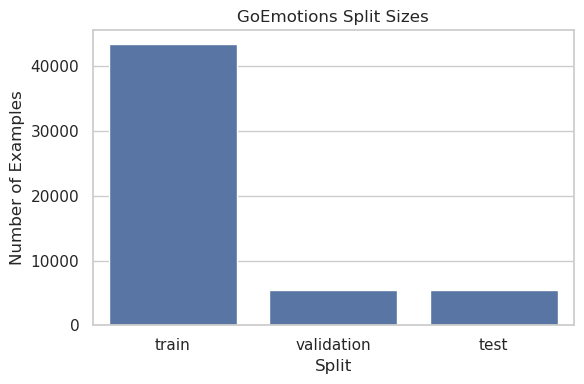

In [26]:
plt.figure(figsize=(6, 4))
sns.barplot(x=list(split_sizes.keys()), y=list(split_sizes.values()))
plt.title("GoEmotions Split Sizes")
plt.xlabel("Split")
plt.ylabel("Number of Examples")
plt.tight_layout()
plt.show()

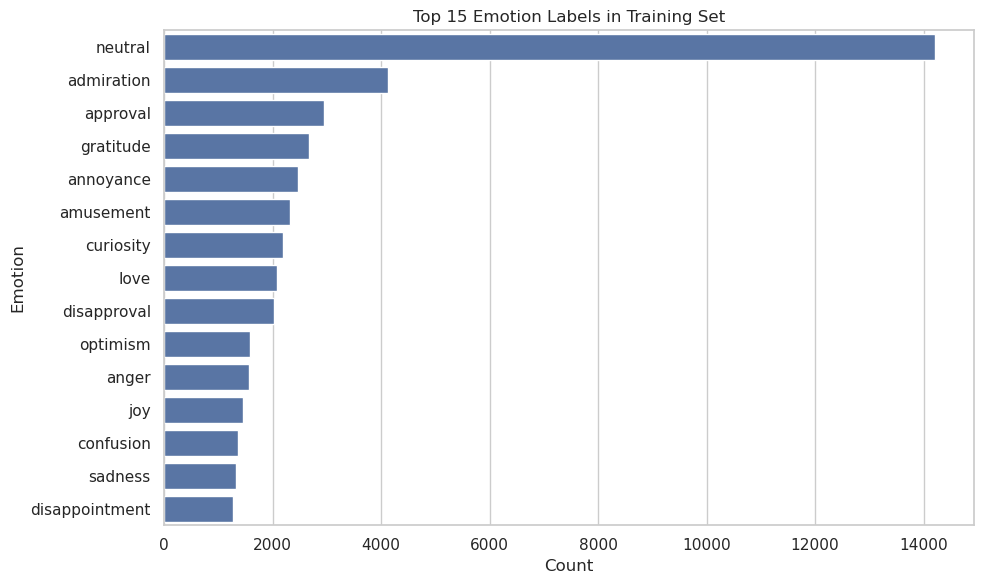

In [27]:
top_k = 15

plt.figure(figsize=(10, 6))
sns.barplot(
    data=train_class_dist.head(top_k),
    x="count",
    y="label"
)
plt.title(f"Top {top_k} Emotion Labels in Training Set")
plt.xlabel("Count")
plt.ylabel("Emotion")
plt.tight_layout()
plt.show()

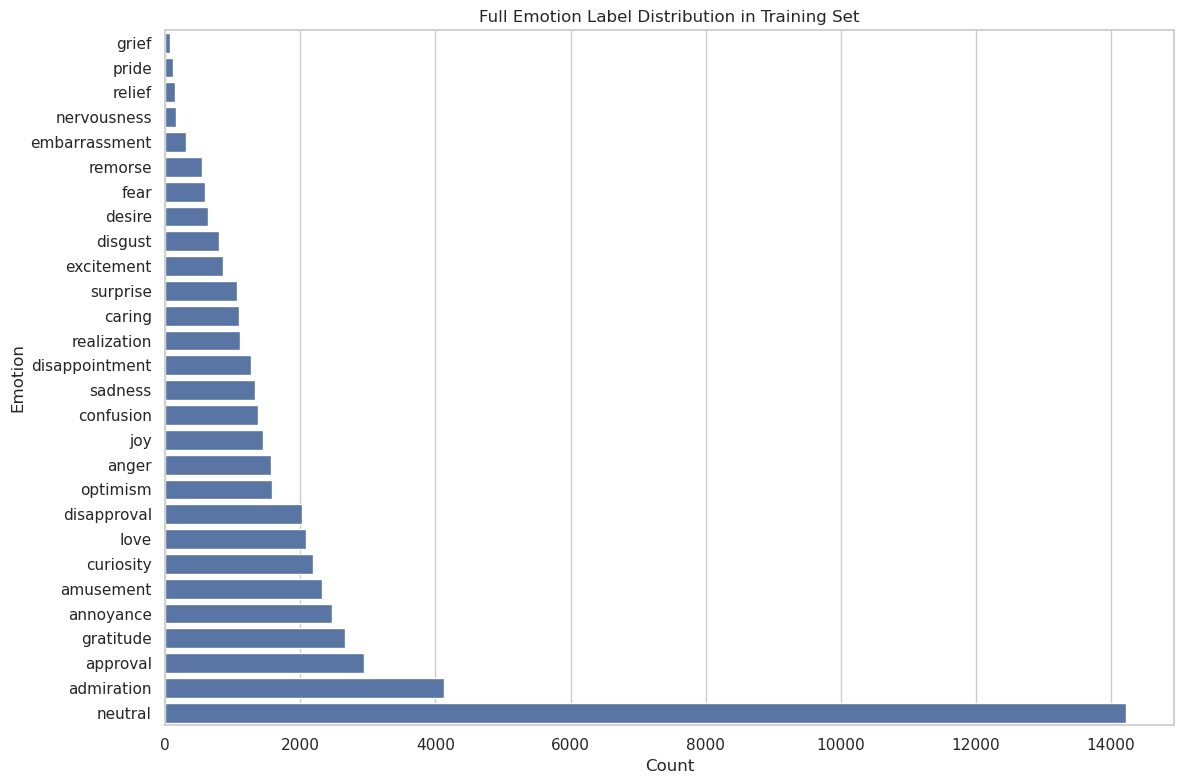

In [28]:
plt.figure(figsize=(12, 8))
sns.barplot(
    data=train_class_dist.sort_values("count", ascending=True),
    x="count",
    y="label"
)
plt.title("Full Emotion Label Distribution in Training Set")
plt.xlabel("Count")
plt.ylabel("Emotion")
plt.tight_layout()
plt.show()

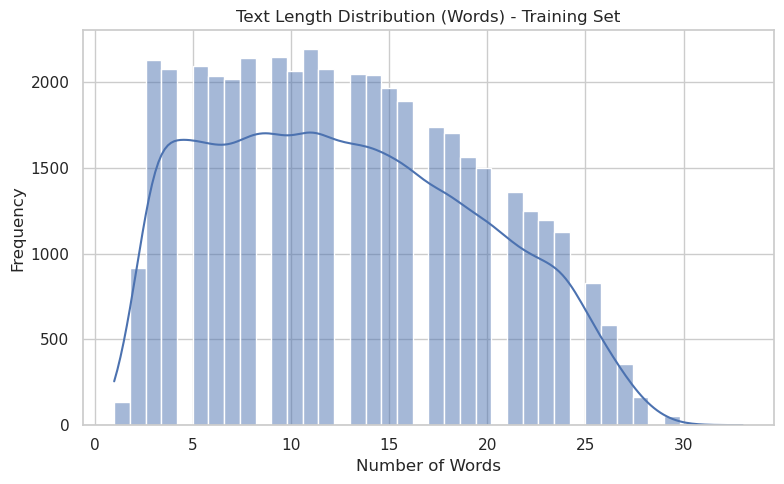

In [29]:
plt.figure(figsize=(8, 5))
sns.histplot(train_df["word_len"], bins=40, kde=True)
plt.title("Text Length Distribution (Words) - Training Set")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

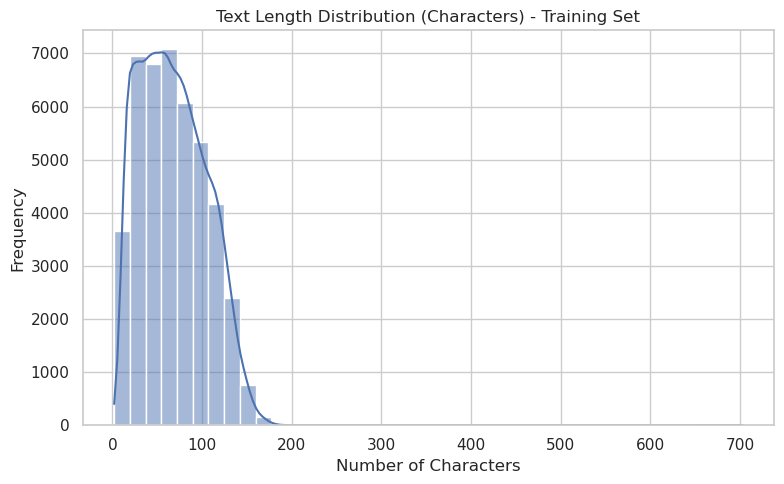

In [30]:
plt.figure(figsize=(8, 5))
sns.histplot(train_df["char_len"], bins=40, kde=True)
plt.title("Text Length Distribution (Characters) - Training Set")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

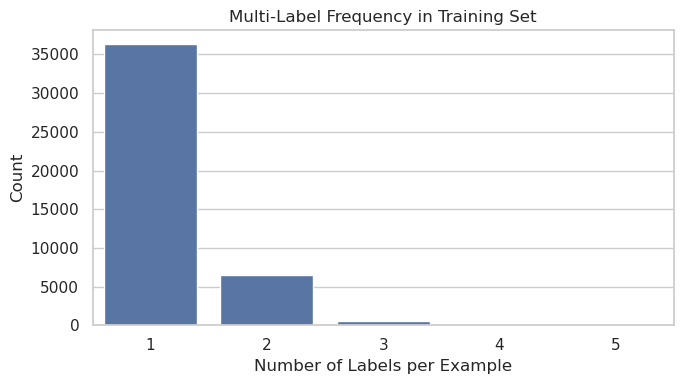

In [31]:
plt.figure(figsize=(7, 4))
sns.barplot(data=multilabel_freq_train, x="num_labels", y="count")
plt.title("Multi-Label Frequency in Training Set")
plt.xlabel("Number of Labels per Example")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

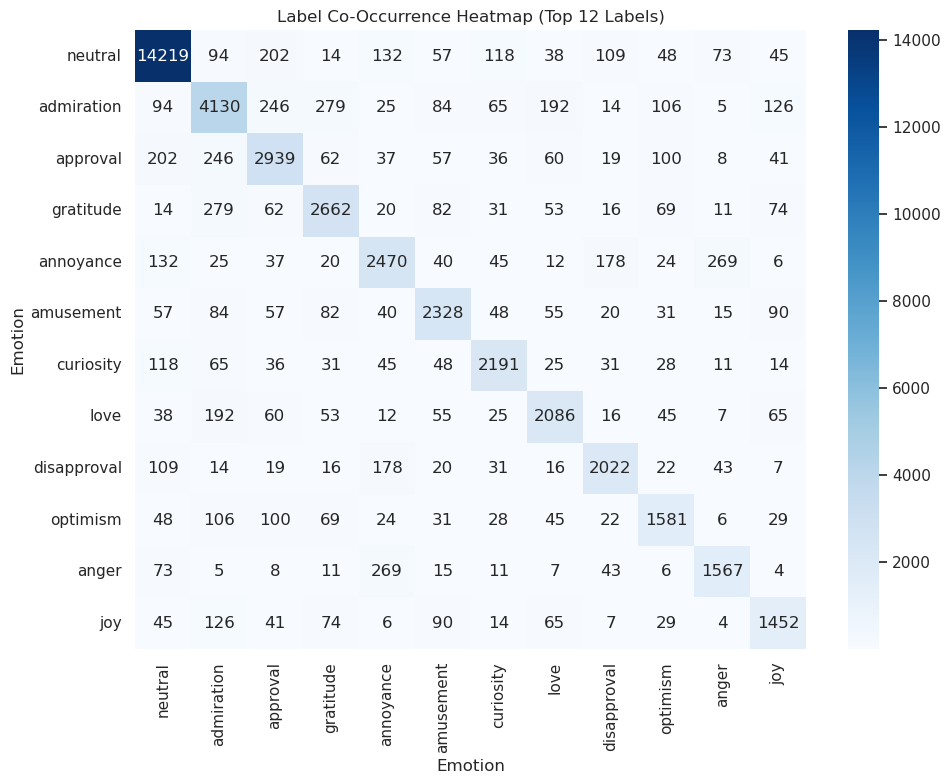

In [32]:
top_labels = train_class_dist.head(12)["label"].tolist()
top_cooccurrence = cooccurrence_train.loc[top_labels, top_labels]

plt.figure(figsize=(10, 8))
sns.heatmap(top_cooccurrence, cmap="Blues", annot=True, fmt="d")
plt.title("Label Co-Occurrence Heatmap (Top 12 Labels)")
plt.xlabel("Emotion")
plt.ylabel("Emotion")
plt.tight_layout()
plt.show()

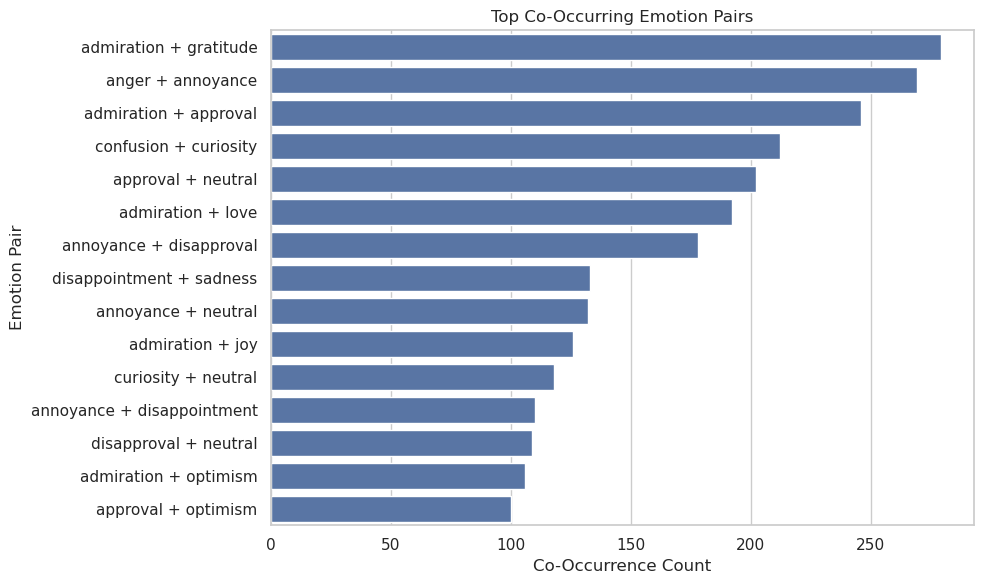

In [33]:
plot_pairs = top_pairs.head(15).copy()
plot_pairs["pair"] = plot_pairs["label_1"] + " + " + plot_pairs["label_2"]

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_pairs, x="count", y="pair")
plt.title("Top Co-Occurring Emotion Pairs")
plt.xlabel("Co-Occurrence Count")
plt.ylabel("Emotion Pair")
plt.tight_layout()
plt.show()

## 13. Additional Inspection Outputs

In [34]:
print("Columns in train_df:")
print(train_df.columns.tolist())

print("Training set label count summary:")
print(train_df["num_labels"].describe())

print("Training set word length summary:")
print(train_df["word_len"].describe())

print("Training set character length summary:")
print(train_df["char_len"].describe())

print("Most frequent labels:")
display(train_class_dist.head(10))

print("\nMulti-label frequency:")
display(multilabel_freq_train)

print("\nTop co-occurring label pairs:")
display(top_pairs)

Columns in train_df:
['text', 'labels', 'id', 'num_labels', 'char_len', 'word_len', 'label_names', 'text_clean_tfidf', 'text_clean_transformer']
Training set label count summary:
count    43410.000000
mean         1.177217
std          0.417699
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          5.000000
Name: num_labels, dtype: float64
Training set word length summary:
count    43410.000000
mean        12.840175
std          6.701597
min          1.000000
25%          7.000000
50%         12.000000
75%         18.000000
max         33.000000
Name: word_len, dtype: float64
Training set character length summary:
count    43410.000000
mean        68.400875
std         36.721898
min          2.000000
25%         38.000000
50%         65.000000
75%         96.000000
max        703.000000
Name: char_len, dtype: float64
Most frequent labels:


,label_id,label,count,percentage_of_examples
0,27,neutral,14219,32.755126
1,0,admiration,4130,9.513937
2,4,approval,2939,6.770329
3,15,gratitude,2662,6.132228
4,3,annoyance,2470,5.689933
5,1,amusement,2328,5.362820
6,7,curiosity,2191,5.047224
7,18,love,2086,4.805344
8,10,disapproval,2022,4.657913
9,20,optimism,1581,3.642018



Multi-label frequency:


,num_labels,count,percentage
0,1,36308,83.639714
1,2,6541,15.067957
2,3,532,1.225524
3,4,28,0.064501
4,5,1,0.002304



Top co-occurring label pairs:


,label_1,label_2,count
0,admiration,gratitude,279
1,anger,annoyance,269
2,admiration,approval,246
3,confusion,curiosity,212
4,approval,neutral,202
5,admiration,love,192
6,annoyance,disapproval,178
7,disappointment,sadness,133
8,annoyance,neutral,132
9,admiration,joy,126


## 14. Export Pipeline (Grouping + Preprocessing + Subsampling)

This section uses `src/label_mapping.py` and `src/data_utils.py` to:
- choose a grouping scheme
- run preprocessing (NLTK or regex)
- save standard processed splits to `data/train.csv`, `data/val.csv`, `data/test.csv`
- save fractional train subsets at 1/5/10/25/50% for one or more seeds


In [35]:
# --- Config ---
GROUP_SCHEME = "pos_neg_ambiguous_neutral"  # or "ekman"
PREPROCESS_MODE = "nltk"  # "nltk" or "regex"
USE_LEMMATIZER = False
DOWNLOAD_NLTK_RESOURCES = True
FRACTIONS = (0.01, 0.05, 0.10, 0.25, 0.50)
SEEDS = (42, 7, 21)
CANONICAL_SEED = 42
OUTPUT_DIR = "data"

# --- Imports from src ---
import sys
from pathlib import Path

repo_root_candidates = [Path.cwd(), Path.cwd().parent]
repo_root = None
for candidate in repo_root_candidates:
    if (candidate / "src" / "data_utils.py").exists():
        repo_root = candidate
        break

if repo_root is None:
    raise FileNotFoundError("Could not locate repo root containing src/data_utils.py")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.data_utils import (
    load_goemotions,
    dataset_to_dataframes,
    add_basic_columns,
    apply_preprocessing,
    remove_empty_rows,
    save_standard_splits,
    save_clean_splits,
    save_fraction_subsamples,
)
from src.label_mapping import (
    get_label_group_mapping,
    validate_label_group_mapping,
    add_grouped_labels_column,
)

# --- Ensure split dataframes/metadata exist ---
if not all(name in globals() for name in ["train_df", "val_df", "test_df", "id2label", "label_names"]):
    dataset, label_names, id2label, label2id = load_goemotions()
    train_df, val_df, test_df = dataset_to_dataframes(dataset, id2label)
else:
    train_df = add_basic_columns(train_df, id2label) if "num_labels" not in train_df.columns else train_df.copy()
    val_df = add_basic_columns(val_df, id2label) if "num_labels" not in val_df.columns else val_df.copy()
    test_df = add_basic_columns(test_df, id2label) if "num_labels" not in test_df.columns else test_df.copy()

# --- Label grouping ---
group_mapping = get_label_group_mapping(GROUP_SCHEME)
_ = validate_label_group_mapping(label_names, group_mapping, allow_unmapped=False)

train_df = add_grouped_labels_column(train_df, id2label, label_group_mapping=group_mapping, output_col="grouped_labels")
val_df = add_grouped_labels_column(val_df, id2label, label_group_mapping=group_mapping, output_col="grouped_labels")
test_df = add_grouped_labels_column(test_df, id2label, label_group_mapping=group_mapping, output_col="grouped_labels")

# --- Text preprocessing ---
train_proc, val_proc, test_proc = apply_preprocessing(
    train_df,
    val_df,
    test_df,
    mode=PREPROCESS_MODE,
    use_lemmatizer=USE_LEMMATIZER,
    download_nltk_resources=DOWNLOAD_NLTK_RESOURCES,
)

train_proc = remove_empty_rows(train_proc, text_col="text_clean_transformer")
val_proc = remove_empty_rows(val_proc, text_col="text_clean_transformer")
test_proc = remove_empty_rows(test_proc, text_col="text_clean_transformer")

# --- Save outputs ---
save_standard_splits(train_proc, val_proc, test_proc, output_dir=OUTPUT_DIR)
save_clean_splits(train_proc, val_proc, test_proc, output_dir=OUTPUT_DIR)

generated = save_fraction_subsamples(
    train_proc,
    output_dir=OUTPUT_DIR,
    fractions=FRACTIONS,
    seeds=SEEDS,
    strategy="labelset_stratified",
    label_col="labels",
    canonical_seed=CANONICAL_SEED,
    write_seeded_files=True,
    write_canonical_aliases=True,
)

print("Export complete.")
print(f"Grouping scheme: {GROUP_SCHEME}")
print(f"Preprocessing mode: {PREPROCESS_MODE}")
print(f"Saved standard splits to: {OUTPUT_DIR}/train.csv, {OUTPUT_DIR}/val.csv, {OUTPUT_DIR}/test.csv")
print(f"Generated fraction subsets: {len(generated)} filesets across {len(SEEDS)} seed(s)")

# Optional quick view
sorted(list(generated.keys()))[:5]


Export complete.
Grouping scheme: pos_neg_ambiguous_neutral
Preprocessing mode: nltk
Saved standard splits to: data/train.csv, data/val.csv, data/test.csv
Generated fraction subsets: 15 filesets across 3 seed(s)


[(0.01, 7), (0.01, 21), (0.01, 42), (0.05, 7), (0.05, 21)]